# Phase 1: The MLP Baseline & Gradient Flow (Air Quality)

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

In [ ]:
CSV_PATH = '../Datasets/delhi_aqi_dataset/delhi_aqi.csv'

WINDOW     = 72   # past 72 hours used as input
HORIZON    = 24   # predict PM2.5 at t+24
BATCH_SIZE = 64
LR         = 1e-3
EPOCHS     = 100

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print('Using device:', device)

Using device: mps


## Data Loading & Sequence Construction


In [ ]:
raw = np.genfromtxt(
    CSV_PATH, delimiter=',', dtype=float,
    skip_header=1, usecols=range(1, 9), filling_values=np.nan
)
print('Raw shape:', raw.shape)   # (18776, 8)
print('Any NaN?', np.isnan(raw).any())

N_FEATURES = raw.shape[1]    # 8
PM25_IDX   = 5               # column index of pm2_5 in the 8-col array

Raw shape: (18776, 8)
Any NaN? False


In [6]:
def build_sequences(data, window=72, horizon=24):
    """Build (X, Y) where X[i] = flattened window of all features,
       Y[i] = pm2_5 value at t+horizon."""
    X, Y = [], []
    for i in range(window, len(data) - horizon):
        X.append(data[i - window : i, :].flatten())   # shape (window*N_FEATURES,)
        Y.append(data[i + horizon, PM25_IDX])          # scalar
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32).reshape(-1, 1)

X_all, Y_all = build_sequences(raw, window=WINDOW, horizon=HORIZON)
print('X shape:', X_all.shape)   # (N_seq, 576)
print('Y shape:', Y_all.shape)   # (N_seq, 1)

X shape: (18680, 576)
Y shape: (18680, 1)


In [ ]:
N          = X_all.shape[0]
train_end  = int(TRAIN_FRAC * N)
val_end    = int((TRAIN_FRAC + VAL_FRAC) * N)

X_train, Y_train = X_all[:train_end],       Y_all[:train_end]
X_val,   Y_val   = X_all[train_end:val_end], Y_all[train_end:val_end]
X_test,  Y_test  = X_all[val_end:],          Y_all[val_end:]

print(f'Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')

mean_x = X_train.mean(axis=0)
std_x  = X_train.std(axis=0) + 1e-10

X_train = (X_train - mean_x) / std_x
X_val   = (X_val   - mean_x) / std_x
X_test  = (X_test  - mean_x) / std_x

y_mean = Y_train.mean()
y_std  = Y_train.std() + 1e-10
Y_train = (Y_train - y_mean) / y_std
Y_val   = (Y_val   - y_mean) / y_std
Y_test  = (Y_test  - y_mean) / y_std

Train: 13076  Val: 2802  Test: 2802


In [14]:
class AQISeqDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_loader = DataLoader(AQISeqDataset(X_train, Y_train), batch_size=BATCH_SIZE, shuffle=False)
val_loader   = DataLoader(AQISeqDataset(X_val,   Y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(AQISeqDataset(X_test,  Y_test),  batch_size=BATCH_SIZE, shuffle=False)

---
## 1.1 Flattened Temporal MLP (Regression)

In [ ]:
class MLP(nn.Module):
    """3-layer MLP for PM2.5 regression."""
    def __init__(self, input_dim, hidden_dim=256, activation=nn.ReLU):
        super().__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.layer3 = nn.Linear(hidden_dim, 1)
        self.act    = activation()

    def forward(self, x):
        x = self.act(self.layer1(x))
        x = self.act(self.layer2(x))
        x = self.layer3(x)
        return x

In [ ]:
def train_regression(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, patience=10):
    """Train regression MLP with early stopping; returns lists of train/val MSE per epoch."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.to(device)

    train_losses, val_losses = [], []
    best_val = float('inf')

    for epoch in range(1, epochs + 1):
        # ── training ────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for X_batch, Y_batch in train_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            optimizer.zero_grad()
            pred  = model(X_batch)
            loss  = criterion(pred, Y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(X_batch)
        train_losses.append(running_loss / len(train_loader.dataset))

        # ── validation ──────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
                pred      = model(X_batch)
                val_loss += criterion(pred, Y_batch).item() * len(X_batch)
        val_losses.append(val_loss / len(val_loader.dataset))

        # ── early stopping ───────────────────────────────────────────────────
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), 'best_model_q1_1.pt')

        if epoch % 5 == 0:
            print(f'Epoch {epoch:3d}/{epochs} | Train MSE: {train_losses[-1]:.2f} | Val MSE: {val_losses[-1]:.2f}')

    # load best weights
    model.load_state_dict(torch.load('best_model_q1_1.pt'))
    return model, train_losses, val_losses


In [26]:
INPUT_DIM  = WINDOW * N_FEATURES   # 72 * 8 = 576
HIDDEN_DIM = 256

mlp_relu = MLP(INPUT_DIM, HIDDEN_DIM, activation=nn.ReLU)
# print(mlp_relu)

mlp_relu, train_losses_relu, val_losses_relu = train_regression(mlp_relu, train_loader, val_loader)

Epoch   5/100 | Train MSE: 0.60 | Val MSE: 0.28
Epoch  10/100 | Train MSE: 0.50 | Val MSE: 0.27
Epoch  15/100 | Train MSE: 0.39 | Val MSE: 0.32
Epoch  20/100 | Train MSE: 0.30 | Val MSE: 0.30
Epoch  25/100 | Train MSE: 0.26 | Val MSE: 0.32
Epoch  30/100 | Train MSE: 0.21 | Val MSE: 0.27
Epoch  35/100 | Train MSE: 0.21 | Val MSE: 0.46
Epoch  40/100 | Train MSE: 0.15 | Val MSE: 0.27
Epoch  45/100 | Train MSE: 0.13 | Val MSE: 0.42
Epoch  50/100 | Train MSE: 0.14 | Val MSE: 0.59
Epoch  55/100 | Train MSE: 0.11 | Val MSE: 0.32
Epoch  60/100 | Train MSE: 0.11 | Val MSE: 0.30
Epoch  65/100 | Train MSE: 0.09 | Val MSE: 0.39
Epoch  70/100 | Train MSE: 0.14 | Val MSE: 0.46
Epoch  75/100 | Train MSE: 0.08 | Val MSE: 0.33
Epoch  80/100 | Train MSE: 0.07 | Val MSE: 0.33
Epoch  85/100 | Train MSE: 0.09 | Val MSE: 0.37
Epoch  90/100 | Train MSE: 0.08 | Val MSE: 0.41
Epoch  95/100 | Train MSE: 0.05 | Val MSE: 0.53
Epoch 100/100 | Train MSE: 0.07 | Val MSE: 0.47


In [27]:
# ── Evaluate on test set ──────────────────────────────────────────────────────
mlp_relu.eval()
criterion = nn.MSELoss()
test_loss = 0.0
with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        pred       = mlp_relu(X_batch)
        test_loss += criterion(pred, Y_batch).item() * len(X_batch)

test_mse = test_loss / len(test_loader.dataset)
print(f'\n[1.1] Test MSE (ReLU MLP): {test_mse:.4f}')


[1.1] Test MSE (ReLU MLP): 1.1314


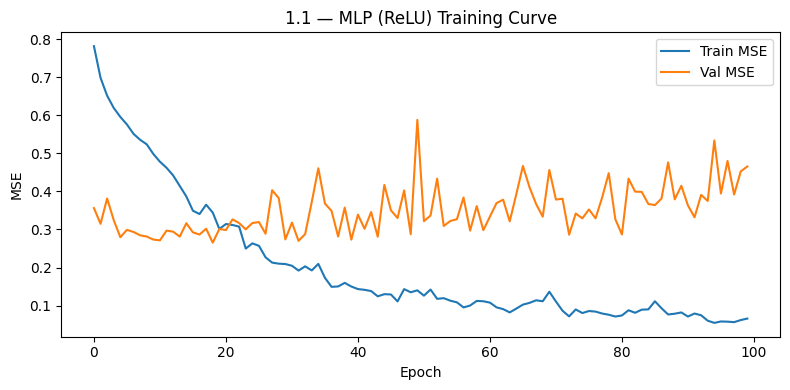

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses_relu, label='Train MSE')
plt.plot(val_losses_relu,   label='Val MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('1.1 — MLP (ReLU) Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
# Re-initialize MLP with Sigmoid activations
mlp_sigmoid = MLP(INPUT_DIM, HIDDEN_DIM, activation=nn.Sigmoid).to(device)

grad_norms = {'layer1': [], 'layer2': [], 'layer3': []}

def make_hook(layer_name):
    def hook(grad):                                   # grad IS the weight gradient
        grad_norms[layer_name].append(grad.norm().item())
    return hook

# Register on the weight tensors directly — fires reliably during backward
mlp_sigmoid.layer1.weight.register_hook(make_hook('layer1'))
mlp_sigmoid.layer2.weight.register_hook(make_hook('layer2'))
mlp_sigmoid.layer3.weight.register_hook(make_hook('layer3'))


In [ ]:
criterion_mse = nn.MSELoss()
optimizer_sig = torch.optim.Adam(mlp_sigmoid.parameters(), lr=LR)

mlp_sigmoid.train()
for X_batch, Y_batch in train_loader:
    X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
    optimizer_sig.zero_grad()
    loss = criterion_mse(mlp_sigmoid(X_batch), Y_batch)
    loss.backward()          # hooks fire here with the actual gradients
    optimizer_sig.step()

print(f"Batches recorded in layer1: {len(grad_norms['layer1'])}")

Batches recorded in layer1: 205


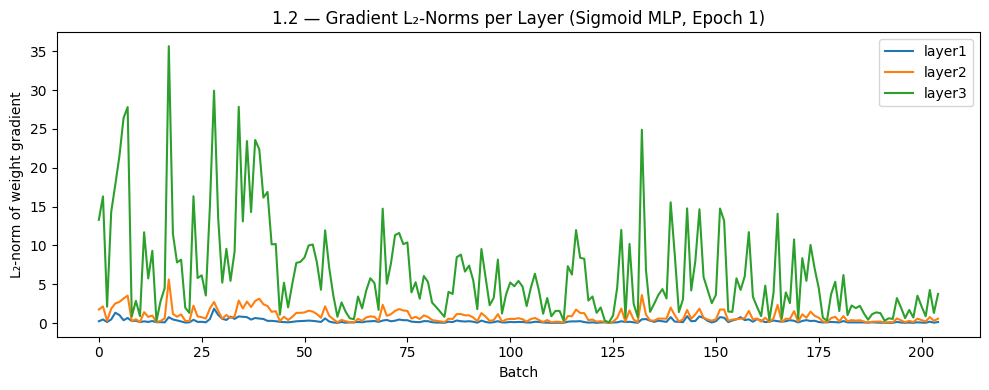

Mean |∇W| — layer1: 0.262829
Mean |∇W| — layer2: 0.886609
Mean |∇W| — layer3: 6.380196


In [ ]:
plt.figure(figsize=(10, 4))
for name, norms in grad_norms.items():
    plt.plot(norms, label=name)
plt.xlabel('Batch')
plt.ylabel('L₂-norm of weight gradient')
plt.title('1.2 — Gradient L₂-Norms per Layer (Sigmoid MLP, Epoch 1)')
plt.legend()
plt.tight_layout()
plt.show()

# Print mean norms to show the decay quantitatively
for name, norms in grad_norms.items():
    print(f'Mean |∇W| — {name}: {np.mean(norms):.6f}')

### Mean gradient norm comparison across layers

A bar chart makes the decay across layers immediately visible.

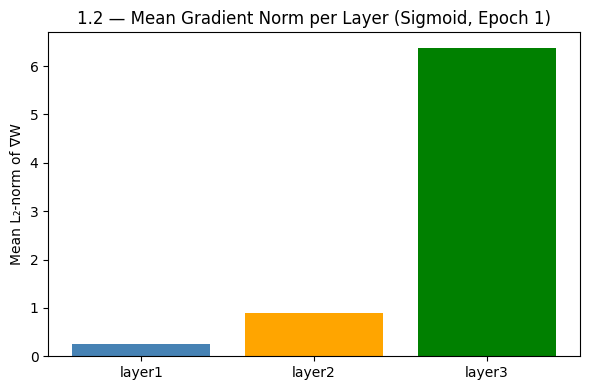

In [35]:
mean_norms = {name: np.mean(norms) for name, norms in grad_norms.items()}

plt.figure(figsize=(6, 4))
plt.bar(mean_norms.keys(), mean_norms.values(), color=['steelblue', 'orange', 'green'])
plt.ylabel('Mean L₂-norm of ∇W')
plt.title('1.2 — Mean Gradient Norm per Layer (Sigmoid, Epoch 1)')
plt.tight_layout()
plt.show()

---
## 1.3 Imbalanced Threshold Classification

Convert PM2.5 → binary label: **1** if PM2.5 > 200 (Hazardous), else **0**.

- **Model A**: trained with standard `BCELoss` (no reweighting).  
- **Model B**: trained with `BCEWithLogitsLoss` + `pos_weight` set to the class-imbalance ratio.

In [ ]:
THRESHOLD = 200   # PM2.5 > 200 → Hazardous (class 1)

Y_binary = (Y_all > THRESHOLD).astype(np.float32)   # shape (N_seq, 1)

Y_train_cls = Y_binary[:train_end]
Y_val_cls   = Y_binary[train_end:val_end]
Y_test_cls  = Y_binary[val_end:]

n_pos = int(Y_train_cls.sum())
n_neg = int(len(Y_train_cls) - n_pos)
pos_weight_value = n_neg / (n_pos + 1e-10)

print(f'Train positives (PM2.5 > 200): {n_pos} / {len(Y_train_cls)} ({100*n_pos/len(Y_train_cls):.1f}%)')
print(f'pos_weight = neg / pos = {pos_weight_value:.2f}')

Train positives (PM2.5 > 200): 5398 / 13076 (41.3%)
pos_weight = neg / pos = 1.42


In [ ]:
# DataLoaders with binary labels 
train_clf_loader = DataLoader(AQISeqDataset(X_train, Y_train_cls), batch_size=BATCH_SIZE, shuffle=False)
val_clf_loader   = DataLoader(AQISeqDataset(X_val,   Y_val_cls),   batch_size=BATCH_SIZE, shuffle=False)
test_clf_loader  = DataLoader(AQISeqDataset(X_test,  Y_test_cls),  batch_size=BATCH_SIZE, shuffle=False)

In [38]:
class MLP_Classifier(nn.Module):
    """3-layer MLP that outputs a raw logit for binary classification."""
    def __init__(self, input_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1)           # raw logit — no sigmoid here
        )

    def forward(self, x):
        return self.net(x)

In [39]:
def train_classifier(model, train_loader, val_loader, criterion, epochs=EPOCHS, lr=LR):
    """Generic classifier training loop."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.to(device)

    train_losses, val_losses = [], []
    for epoch in range(1, epochs + 1):
        # ── training ────────────────────────────────────────────────────────
        model.train()
        running = 0.0
        for X_b, Y_b in train_loader:
            X_b, Y_b = X_b.to(device), Y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), Y_b)
            loss.backward()
            optimizer.step()
            running += loss.item() * len(X_b)
        train_losses.append(running / len(train_loader.dataset))

        # ── validation ──────────────────────────────────────────────────────
        model.eval()
        val_l = 0.0
        with torch.no_grad():
            for X_b, Y_b in val_loader:
                X_b, Y_b = X_b.to(device), Y_b.to(device)
                val_l += criterion(model(X_b), Y_b).item() * len(X_b)
        val_losses.append(val_l / len(val_loader.dataset))

        if epoch % 5 == 0:
            print(f'Epoch {epoch:3d}/{epochs} | Train loss: {train_losses[-1]:.4f} | Val loss: {val_losses[-1]:.4f}')

    return train_losses, val_losses

In [ ]:
print('=== Model A: BCELoss (standard) ===')

model_A   = MLP_Classifier(INPUT_DIM, HIDDEN_DIM)

# BCELoss expects probabilities; we apply sigmoid inside the loss manually
# by using BCEWithLogitsLoss without pos_weight (equivalent to BCELoss + sigmoid)
criterion_A = nn.BCEWithLogitsLoss()   # no pos_weight -> standard BCE

train_classifier(model_A, train_clf_loader, val_clf_loader, criterion_A)

=== Model A: BCELoss (standard) ===
Epoch   5/100 | Train loss: 0.4774 | Val loss: 0.3647
Epoch  10/100 | Train loss: 0.4320 | Val loss: 0.3602
Epoch  15/100 | Train loss: 0.3716 | Val loss: 0.3950
Epoch  20/100 | Train loss: 0.2831 | Val loss: 0.5006
Epoch  25/100 | Train loss: 0.2348 | Val loss: 0.6102
Epoch  30/100 | Train loss: 0.1411 | Val loss: 0.7960
Epoch  35/100 | Train loss: 0.1366 | Val loss: 0.8988
Epoch  40/100 | Train loss: 0.1152 | Val loss: 1.1089
Epoch  45/100 | Train loss: 0.0513 | Val loss: 1.2056
Epoch  50/100 | Train loss: 0.1048 | Val loss: 1.0701
Epoch  55/100 | Train loss: 0.0598 | Val loss: 1.3959
Epoch  60/100 | Train loss: 0.0573 | Val loss: 1.5220
Epoch  65/100 | Train loss: 0.0515 | Val loss: 1.3726
Epoch  70/100 | Train loss: 0.0570 | Val loss: 1.5312
Epoch  75/100 | Train loss: 0.0414 | Val loss: 1.6062
Epoch  80/100 | Train loss: 0.0259 | Val loss: 1.9078
Epoch  85/100 | Train loss: 0.0356 | Val loss: 1.5963
Epoch  90/100 | Train loss: 0.0384 | Val loss:

([0.5652944172657605,
  0.5196023596175477,
  0.5081683572332732,
  0.4911943463857621,
  0.47743690267328315,
  0.4665857847767454,
  0.4602991408913753,
  0.4506147597389653,
  0.44019937249052665,
  0.43196668411366035,
  0.4210754363097048,
  0.4133757651946201,
  0.39774265706210954,
  0.38223642057492196,
  0.37157663404622476,
  0.36119381546445417,
  0.345152073467715,
  0.3296255692953581,
  0.30388103702876795,
  0.2831491524739372,
  0.26815535339280966,
  0.25206353139581256,
  0.2359079111443816,
  0.226617950874299,
  0.23479720998367873,
  0.2070182497545042,
  0.18633219226140674,
  0.1577713048435208,
  0.15031502242523412,
  0.14111436831198718,
  0.13573303125296146,
  0.14717804593494777,
  0.14786346392364447,
  0.1531722179706278,
  0.1366225445242291,
  0.10827424768426487,
  0.12444174707441491,
  0.12827534816882685,
  0.1251839056642936,
  0.11521923903898433,
  0.0933354727802676,
  0.14026811075283768,
  0.11570422338217747,
  0.0660717849919966,
  0.0513407

In [41]:
print('=== Model B: BCEWithLogitsLoss + pos_weight ===')

model_B = MLP_Classifier(INPUT_DIM, HIDDEN_DIM)

pw = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
criterion_B = nn.BCEWithLogitsLoss(pos_weight=pw)

train_classifier(model_B, train_clf_loader, val_clf_loader, criterion_B)

=== Model B: BCEWithLogitsLoss + pos_weight ===
Epoch   5/100 | Train loss: 0.5667 | Val loss: 0.4596
Epoch  10/100 | Train loss: 0.5196 | Val loss: 0.4683
Epoch  15/100 | Train loss: 0.4482 | Val loss: 0.5280
Epoch  20/100 | Train loss: 0.3482 | Val loss: 0.6538
Epoch  25/100 | Train loss: 0.2809 | Val loss: 0.8089
Epoch  30/100 | Train loss: 0.2034 | Val loss: 1.1060
Epoch  35/100 | Train loss: 0.1520 | Val loss: 1.2849
Epoch  40/100 | Train loss: 0.0860 | Val loss: 1.4906
Epoch  45/100 | Train loss: 0.1487 | Val loss: 1.4629
Epoch  50/100 | Train loss: 0.0631 | Val loss: 1.8421
Epoch  55/100 | Train loss: 0.0812 | Val loss: 1.6945
Epoch  60/100 | Train loss: 0.0369 | Val loss: 2.0459
Epoch  65/100 | Train loss: 0.0494 | Val loss: 2.0105
Epoch  70/100 | Train loss: 0.0400 | Val loss: 2.2049
Epoch  75/100 | Train loss: 0.0445 | Val loss: 2.2417
Epoch  80/100 | Train loss: 0.0801 | Val loss: 2.2410
Epoch  85/100 | Train loss: 0.0662 | Val loss: 1.8839
Epoch  90/100 | Train loss: 0.0347

([0.6690183443080836,
  0.6158116254402833,
  0.5959944777229431,
  0.5842706600700398,
  0.5666501075804288,
  0.5609480990259317,
  0.5458008576402171,
  0.539417938934112,
  0.5293551437914572,
  0.5195824903526887,
  0.510488305563371,
  0.4941832445500349,
  0.4817926899013478,
  0.46301435498003934,
  0.4481611819593102,
  0.43386269138790334,
  0.4141576559071732,
  0.3932572067166804,
  0.3704897330925165,
  0.3482188545817007,
  0.3382429171475514,
  0.30886021661909757,
  0.28314831948922603,
  0.27598889175268004,
  0.28091348802708976,
  0.24490509386441897,
  0.21854597309125093,
  0.217446367642234,
  0.21011835459873887,
  0.20338782261511207,
  0.17512095377587622,
  0.15758420468399767,
  0.16389004679857708,
  0.1530694679543353,
  0.1520411420637957,
  0.1405513839220006,
  0.14348572428619136,
  0.14889896797144667,
  0.10383431672114117,
  0.08600009558133,
  0.07336661479318836,
  0.08062388599268623,
  0.07790422045407258,
  0.08961798312184086,
  0.1487372732219

In [42]:
def get_predictions(model, loader):
    """Return sigmoid probabilities and true labels from the test set."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_b, Y_b in loader:
            logits = model(X_b.to(device)).cpu()
            probs  = torch.sigmoid(logits).numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(Y_b.numpy().flatten())
    return np.array(all_probs), np.array(all_labels)

probs_A, labels = get_predictions(model_A, test_clf_loader)
probs_B, _      = get_predictions(model_B, test_clf_loader)

precision_A, recall_A, _ = precision_recall_curve(labels, probs_A)
precision_B, recall_B, _ = precision_recall_curve(labels, probs_B)

ap_A = average_precision_score(labels, probs_A)
ap_B = average_precision_score(labels, probs_B)

print(f'Average Precision — Model A (no pos_weight):   {ap_A:.4f}')
print(f'Average Precision — Model B (with pos_weight): {ap_B:.4f}')

Average Precision — Model A (no pos_weight):   0.7838
Average Precision — Model B (with pos_weight): 0.7890


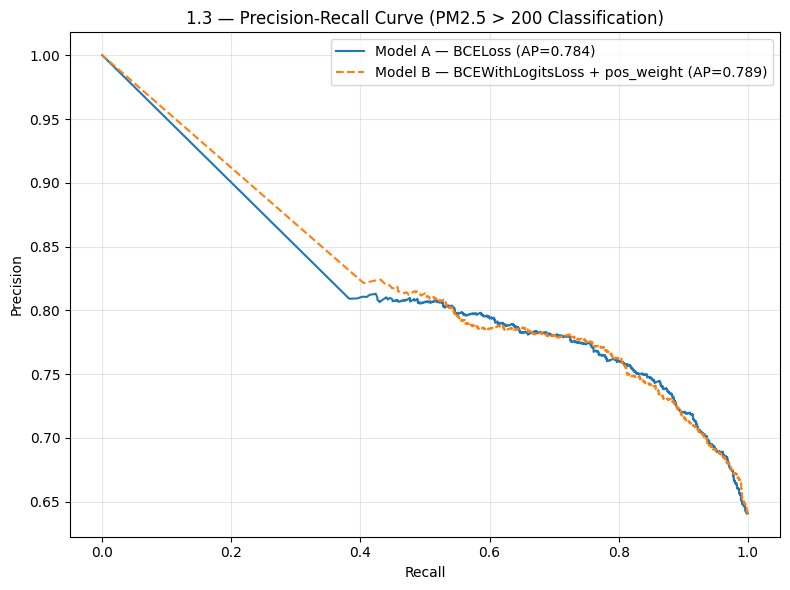

In [43]:
plt.figure(figsize=(8, 6))
plt.plot(recall_A, precision_A, label=f'Model A — BCELoss (AP={ap_A:.3f})')
plt.plot(recall_B, precision_B, label=f'Model B — BCEWithLogitsLoss + pos_weight (AP={ap_B:.3f})', linestyle='--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('1.3 — Precision-Recall Curve (PM2.5 > 200 Classification)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()